💡 **Environment:** `clamp-analyses`

# Description

**Sandbox NB 05 — does null-adjustment change the headline AUROCs? (paired bootstrap).**

Reads NB04's aggregated 685-pair frame (gene-based + module ARCHS4 × {raw, pearson, background}) and:

1. Reports AUROC / AUPRC per (method, scoring); reproduces the published raw numbers.
2. **Paired bootstrap** (reusing `signif_test/01` machinery: shared resample of the 685 pairs,
   `boot_ci`, `boot_pvalue_two_sided`, `bh_correct`): tests, with a 95% CI on the metric *difference*,
   - within each method: raw vs pearson, raw vs background (does adjustment help?);
   - cross-method: ARCHS4 vs gene under each scoring (does adjustment change the ~4-pp gap?).
3. Plots + `FINDINGS_multitissue.md`.

All comparisons share the *identical* 685 (drug, DOID) pairs (asserted in NB04), so each bootstrap
iteration applies the **same** resample indices to both sides — this pairing is the whole point.
See `CLAUDE.md`.

# Modules loading

In [1]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

from pyprojroot import here

# Settings

In [2]:
SEED = 42
N_BOOT = 10000
METRICS = {'AUROC': roc_auc_score, 'AUPRC': average_precision_score}

OUTPUT_DIR = here(
    'output/03_model_biology/00_archs4/02_drug_disease_associations/null_adjust_test')
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

METHODS = ['gene_based', 'module_based_archs4']
SCORINGS = ['raw', 'pearson', 'background']

# Load aggregated frame; pivot to a shared (drug, DOID) × (method, scoring) table

In [3]:
agg = pd.read_pickle(OUTPUT_DIR / 'predictions_multitissue_aggregated.pkl')
print('aggregated:', agg.shape)

agg['col'] = agg['method'].astype(str) + '|' + agg['scoring'].astype(str)
wide = agg.pivot_table(index=['trait', 'drug'], columns='col', values='score', observed=True)
y_true = (agg.groupby(['trait', 'drug'], observed=True)['true_class']
          .agg(lambda s: s.iloc[0]).reindex(wide.index).astype(int).values)

COLS = [f'{m}|{s}' for m in METHODS for s in SCORINGS]
assert wide[COLS].notna().all().all(), 'columns differ in pair coverage'
n = len(y_true)
print('paired pairs:', n, '| positives:', int(y_true.sum()), '| negatives:', int((1 - y_true).sum()))
scores = {c: wide[c].values for c in COLS}

aggregated: (4110, 6)
paired pairs: 685 | positives: 531 | negatives: 154


# Observed AUROC / AUPRC per (method, scoring)

In [4]:
obs = []
for c in COLS:
    m, s = c.split('|')
    row = {'method': m, 'scoring': s}
    for mn, mf in METRICS.items():
        row[mn] = mf(y_true, scores[c])
    obs.append(row)
obs = pd.DataFrame(obs)
display(obs.pivot(index='method', columns='scoring', values='AUROC'))
display(obs.pivot(index='method', columns='scoring', values='AUPRC'))

# reproduce published raw numbers
raw_auroc = obs[(obs.scoring == 'raw')].set_index('method')['AUROC']
print('raw AUROC:', dict(raw_auroc.round(4)))
assert abs(raw_auroc['gene_based'] - 0.583) < 0.02
assert abs(raw_auroc['module_based_archs4'] - 0.625) < 0.02

scoring,background,pearson,raw
method,,,
gene_based,0.484616,0.525962,0.583028
module_based_archs4,0.518447,0.524782,0.625419


scoring,background,pearson,raw
method,,,
gene_based,0.779731,0.794021,0.844822
module_based_archs4,0.799255,0.804863,0.849646


raw AUROC: {'gene_based': np.float64(0.583), 'module_based_archs4': np.float64(0.6254)}


# Bootstrap helpers (copied verbatim from signif_test/01)

In [5]:
def boot_ci(arr, lo=2.5, hi=97.5):
    return np.percentile(arr, lo), np.percentile(arr, hi)


def boot_pvalue_two_sided(diffs):
    """Two-sided bootstrap p-value for H0: diff == 0, (count+1)/(N+1) convention."""
    n = len(diffs)
    p_le = ((diffs <= 0).sum() + 1) / (n + 1)
    p_ge = ((diffs >= 0).sum() + 1) / (n + 1)
    return min(2.0 * min(p_le, p_ge), 1.0)


def bh_correct(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = ranked * m / (np.arange(m) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    out = np.empty(m)
    out[order] = np.minimum(adj, 1.0)
    return out

# Paired bootstrap (shared resample over the 685 pairs)

In [6]:
np.random.seed(SEED)
boot = {mn: {c: [] for c in COLS} for mn in METRICS}
n_skipped = 0
for _ in range(N_BOOT):
    idx = np.random.choice(n, n, replace=True)   # SAME resample for every column
    yb = y_true[idx]
    if len(np.unique(yb)) < 2:
        n_skipped += 1
        continue
    for mn, mf in METRICS.items():
        for c in COLS:
            boot[mn][c].append(mf(yb, scores[c][idx]))
boot = {mn: {c: np.asarray(v) for c, v in d.items()} for mn, d in boot.items()}
print('bootstrap done; skipped:', n_skipped)

bootstrap done; skipped: 0


# Comparisons: within-method (raw vs adjusted) and cross-method (ARCHS4 vs gene)

In [7]:
COMPARISONS = []
for m in METHODS:                                  # within method: adjusted vs raw
    for s in ['pearson', 'background']:
        COMPARISONS.append((f'{m}|{s}', f'{m}|raw', f'{m}: {s} vs raw'))
for s in SCORINGS:                                 # cross method under each scoring
    COMPARISONS.append((f'module_based_archs4|{s}', f'gene_based|{s}',
                        f'ARCHS4 vs gene ({s})'))

rows = []
for mn in METRICS:
    for B, A, label in COMPARISONS:
        diff = boot[mn][B] - boot[mn][A]
        lo, hi = boot_ci(diff)
        rows.append({
            'metric': mn, 'comparison': label,
            f'{mn}_A': METRICS[mn](y_true, scores[A]),
            f'{mn}_B': METRICS[mn](y_true, scores[B]),
            'diff_obs': METRICS[mn](y_true, scores[B]) - METRICS[mn](y_true, scores[A]),
            'diff_ci_lo': lo, 'diff_ci_hi': hi,
            'ci_excludes_0': bool(lo > 0 or hi < 0),
            'p_value': boot_pvalue_two_sided(diff),
        })
results = pd.DataFrame(rows)
results['p_value_bh'] = bh_correct(results['p_value'].values)
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 20)
display(results)
results.to_csv(OUTPUT_DIR / 'multitissue_bootstrap_results.csv', index=False)

,metric,comparison,AUROC_A,AUROC_B,diff_obs,diff_ci_lo,diff_ci_hi,ci_excludes_0,p_value,AUPRC_A,AUPRC_B,p_value_bh
0,AUROC,gene_based: pearson vs raw,0.583028,0.525962,-0.057066,-0.098110,-0.014562,True,0.009399,NaN,NaN,0.016448
1,AUROC,gene_based: background vs raw,0.583028,0.484616,-0.098411,-0.137111,-0.058440,True,0.000200,NaN,NaN,0.000700
2,AUROC,module_based_archs4: pearson vs raw,0.625419,0.524782,-0.100637,-0.146891,-0.053626,True,0.000200,NaN,NaN,0.000700
3,AUROC,module_based_archs4: background vs raw,0.625419,0.518447,-0.106972,-0.150999,-0.062103,True,0.000200,NaN,NaN,0.000700
4,AUROC,ARCHS4 vs gene (raw),0.583028,0.625419,0.042391,0.000100,0.084619,True,0.049595,NaN,NaN,0.077148
5,AUROC,ARCHS4 vs gene (pearson),0.525962,0.524782,-0.001180,-0.062196,0.058116,False,0.958504,NaN,NaN,0.958504
6,AUROC,ARCHS4 vs gene (background),0.484616,0.518447,0.033831,-0.024172,0.090514,False,0.247975,NaN,NaN,0.315859
7,AUPRC,gene_based: pearson vs raw,NaN,NaN,-0.050801,-0.076355,-0.022526,True,0.000400,0.844822,0.794021,0.001120
8,AUPRC,gene_based: background vs raw,NaN,NaN,-0.065092,-0.090319,-0.039721,True,0.000200,0.844822,0.779731,0.000700
9,AUPRC,module_based_archs4: pearson vs raw,NaN,NaN,-0.044783,-0.075767,-0.013380,True,0.004200,0.849646,0.804863,0.008399


# Plots

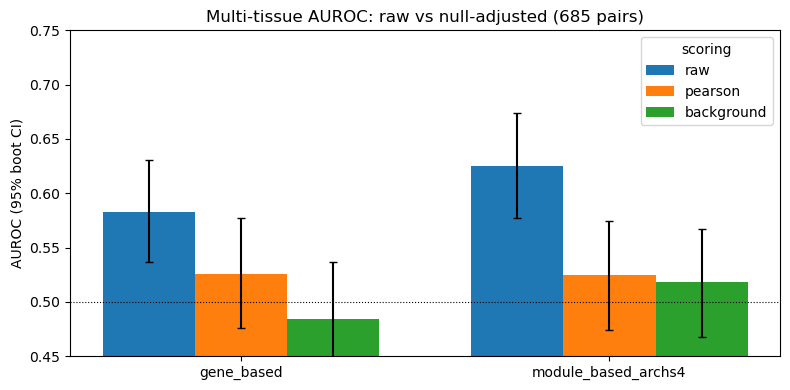

In [8]:
# 1) AUROC per method x scoring with bootstrap 95% CI
fig, ax = plt.subplots(figsize=(8, 4))
xpos = np.arange(len(METHODS)); width = 0.25
for j, s in enumerate(SCORINGS):
    means, los, his = [], [], []
    for m in METHODS:
        b = boot['AUROC'][f'{m}|{s}']
        means.append(METRICS['AUROC'](y_true, scores[f'{m}|{s}']))
        lo, hi = boot_ci(b); los.append(lo); his.append(hi)
    means = np.array(means)
    ax.bar(xpos + (j - 1) * width, means, width, label=s,
           yerr=[means - np.array(los), np.array(his) - means], capsize=3)
ax.axhline(0.5, color='k', ls=':', lw=0.8)
ax.set_xticks(xpos); ax.set_xticklabels(METHODS); ax.set_ylim(0.45, 0.75)
ax.set_ylabel('AUROC (95% boot CI)'); ax.legend(title='scoring')
ax.set_title('Multi-tissue AUROC: raw vs null-adjusted (685 pairs)')
fig.tight_layout(); fig.savefig(FIG_DIR / 'multitissue_auroc.png', dpi=110, bbox_inches='tight')
plt.show()

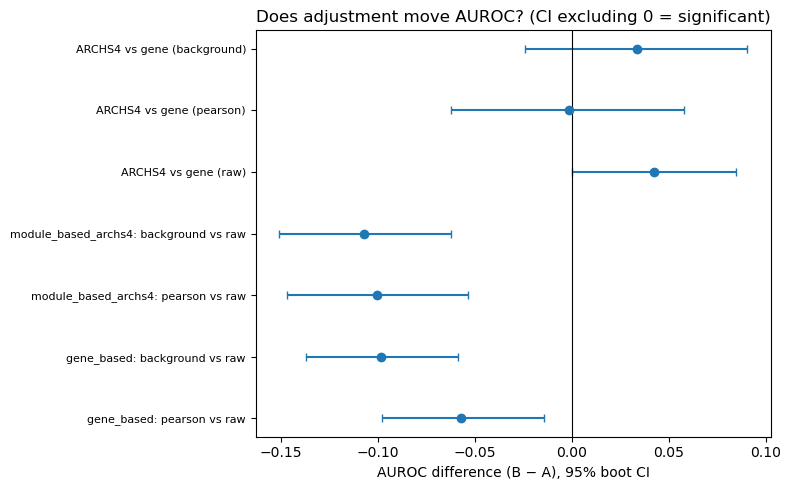

In [9]:
# 2) Difference CIs (forest) for AUROC
fig, ax = plt.subplots(figsize=(8, 5))
sub = results[results.metric == 'AUROC'].reset_index(drop=True)
ypos = np.arange(len(sub))
ax.errorbar(sub['diff_obs'], ypos,
            xerr=[sub['diff_obs'] - sub['diff_ci_lo'], sub['diff_ci_hi'] - sub['diff_obs']],
            fmt='o', capsize=3)
ax.axvline(0, color='k', lw=0.8)
ax.set_yticks(ypos); ax.set_yticklabels(sub['comparison'], fontsize=8)
ax.set_xlabel('AUROC difference (B − A), 95% boot CI')
ax.set_title('Does adjustment move AUROC? (CI excluding 0 = significant)')
fig.tight_layout(); fig.savefig(FIG_DIR / 'multitissue_auroc_diff.png', dpi=110, bbox_inches='tight')
plt.show()

# Findings

In [10]:
lines = ['# Findings — multi-tissue / top-N null adjustment (gene-based + module ARCHS4)', '']
lines.append('Scope: 49 tissues x 5 top-N thresholds, 685-pair PharmacotherapyDB universe, '
             f'paired bootstrap N={N_BOOT} (seed {SEED}).')
lines.append('')
lines.append('## AUROC by method x scoring')
pa = obs.pivot(index='method', columns='scoring', values='AUROC')
for m in METHODS:
    lines.append(f'- {m}: ' + ', '.join(f'{s}={pa.loc[m, s]:.4f}' for s in SCORINGS))
lines.append('')
lines.append('## Does adjustment help / change the gap? (AUROC differences)')
for _, r in results[results.metric == 'AUROC'].iterrows():
    sig = 'SIGNIFICANT' if r['ci_excludes_0'] else 'n.s.'
    lines.append(f"- {r['comparison']}: diff={r['diff_obs']:+.4f} "
                 f"[{r['diff_ci_lo']:+.4f}, {r['diff_ci_hi']:+.4f}], "
                 f"p={r['p_value']:.3f} (BH {r['p_value_bh']:.3f}) -> {sig}")
lines.append('')
lines.append('## Read')
lines.append('- Raw reproduces published gene≈0.583 / ARCHS4≈0.625.')
lines.append('- Adjustment columns above show whether per-cell Pearson / background normalization '
             'moves the headline AUROC or the ARCHS4-vs-gene gap. Report the CI/significance '
             'faithfully (a null result is a valid outcome consistent with the Phase-1 finding that '
             'per-cell adjustment mostly preserves within-disease ranking).')
lines.append('')
lines.append('## Caveats')
lines.append('- Pearson is the analytic equivalent of the permute-disease null (NB04 spot-check). '
             'Background is a competitive null (uses other DOIDs as the reference). '
             'Z-shuffle is not evaluated at scale (NB03 prototype only). GTEx/recount2 excluded.')
summary = '\n'.join(lines)
(OUTPUT_DIR / 'FINDINGS_multitissue.md').write_text(summary)
print(summary)

# Findings — multi-tissue / top-N null adjustment (gene-based + module ARCHS4)

Scope: 49 tissues x 5 top-N thresholds, 685-pair PharmacotherapyDB universe, paired bootstrap N=10000 (seed 42).

## AUROC by method x scoring
- gene_based: raw=0.5830, pearson=0.5260, background=0.4846
- module_based_archs4: raw=0.6254, pearson=0.5248, background=0.5184

## Does adjustment help / change the gap? (AUROC differences)
- gene_based: pearson vs raw: diff=-0.0571 [-0.0981, -0.0146], p=0.009 (BH 0.016) -> SIGNIFICANT
- gene_based: background vs raw: diff=-0.0984 [-0.1371, -0.0584], p=0.000 (BH 0.001) -> SIGNIFICANT
- module_based_archs4: pearson vs raw: diff=-0.1006 [-0.1469, -0.0536], p=0.000 (BH 0.001) -> SIGNIFICANT
- module_based_archs4: background vs raw: diff=-0.1070 [-0.1510, -0.0621], p=0.000 (BH 0.001) -> SIGNIFICANT
- ARCHS4 vs gene (raw): diff=+0.0424 [+0.0001, +0.0846], p=0.050 (BH 0.077) -> SIGNIFICANT
- ARCHS4 vs gene (pearson): diff=-0.0012 [-0.0622, +0.0581], p=0.959 (BH 0.959) ->